In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/MALLORN Astronomical Classification Challenge/mallorn-astronomical-classification-challenge"

train_log = pd.read_csv(f"{BASE_PATH}/train_log.csv")
test_log  = pd.read_csv(f"{BASE_PATH}/test_log.csv")
print(train_log.shape, test_log.shape)
print(train_log.columns)

(3043, 8) (7135, 7)
Index(['object_id', 'Z', 'Z_err', 'EBV', 'SpecType', 'English Translation',
       'split', 'target'],
      dtype='object')


In [ ]:
train=train_log.drop(columns=['SpecType','English Translation'])
test=test_log.drop(columns=['SpecType','English Translation'])

In [ ]:
len(test['object_id'].unique()), test.shape

(7135, (7135, 5))

In [ ]:
train_full_lightcurves=pd.read_csv(f"{BASE_PATH}/split_01/train_full_lightcurves.csv")
train_full_lightcurves.head()

,object_id,Time (MJD),Flux,Flux_err,Filter
0,Dornhoth_fervain_onodrim,63314.4662,-1.630159,0.365777,z
1,Dornhoth_fervain_onodrim,63780.9674,10.499389,0.253867,r
2,Dornhoth_fervain_onodrim,63789.7693,5.866250,1.559241,y
3,Dornhoth_fervain_onodrim,63794.1702,3.903623,0.376854,r
4,Dornhoth_fervain_onodrim,63794.1702,5.226644,0.516864,i


In [ ]:
# split_data = {}

# for split_name in train_log["split"].unique():
#     split_path = os.path.join(BASE_PATH, split_name, "train_full_lightcurves.csv")
#     df = pd.read_csv(split_path)
#     split_data[split_name] = df
#     print(split_name, df.shape)

## Training

In [ ]:
def build_object_features(lc, meta):
    f = lc["Flux"].values
    t = lc["Time (MJD)"].values
    ferr = lc["Flux_err"].values

    feats = {}
    # -------- Global lightcurve behavior --------
    feats["n_obs"] = len(lc)
    feats["flux_mean"] = np.mean(f)
    feats["flux_std"]  = np.std(f)
    feats["flux_max"]  = np.max(f)
    feats["flux_min"]  = np.min(f)
    feats["flux_amp"]  = feats["flux_max"] - feats["flux_min"]
    feats["flux_iqr"]  = np.percentile(f,75) - np.percentile(f,25)
    # -------- Temporal shape --------
    peak_idx = np.argmax(f)
    feats["t_peak"] = t[peak_idx]
    feats["rise_time"]  = t[peak_idx] - t.min()
    feats["decay_time"] = t.max() - t[peak_idx]
    if len(t) > 1:
        dt = np.diff(t)
        df = np.diff(f)
        mask = dt > 0
        slopes = df[mask] / dt[mask] if mask.any() else np.array([0])
        feats["slope_mean"] = slopes.mean()
        feats["slope_std"]  = slopes.std()
        feats["slope_max"]  = slopes.max()
    else:
        feats["slope_mean"] = feats["slope_std"] = feats["slope_max"] = 0
    # -------- Uncertainty behavior --------
    feats["fluxerr_mean"] = np.mean(ferr)
    feats["snr_mean"] = np.mean(np.abs(f) / (ferr + 1e-6))
    # -------- Filter-specific behavior --------
    for band in ["u","g","r","i","z","y"]:
        sub = lc[lc["Filter"] == band]
        if len(sub) == 0:
            for name in ["mean","std","max","min","n"]:
                feats[f"{band}_{name}"] = 0
        else:
            feats[f"{band}_mean"] = sub["Flux"].mean()
            feats[f"{band}_std"]  = sub["Flux"].std()
            feats[f"{band}_max"]  = sub["Flux"].max()
            feats[f"{band}_min"]  = sub["Flux"].min()
            feats[f"{band}_n"]    = len(sub)
    # -------- Metadata from train_log --------
    feats["Z"] = meta["Z"]
    feats["Z_err"] = meta["Z_err"]
    feats["EBV"] = meta["EBV"]
    # --- curvature & asymmetry ---
    if len(t) > 2:
        d1 = np.diff(f)
        d2 = np.diff(d1)
        feats["curvature_mean"] = d2.mean()
        feats["curvature_std"]  = d2.std()
    else:
        feats["curvature_mean"] = 0
        feats["curvature_std"]  = 0
    # --- flux / error interaction ---
    feats["snr_std"] = np.std(np.abs(f) / (ferr + 1e-6))
    feats["fluxerr_ratio"] = feats["flux_std"] / (feats["fluxerr_mean"] + 1e-6)
    return feats

In [ ]:
train_rows = []
for _, row in train_log.iterrows():
    obj = row["object_id"]
    split = row["split"]

    lc = pd.read_csv(f"{BASE_PATH}/{split}/train_full_lightcurves.csv")
    lc = lc[lc["object_id"] == obj]

    feats = build_object_features(lc, row)
    feats["object_id"] = obj
    feats["target"] = row["target"]

    train_rows.append(feats)

train_features = pd.DataFrame(train_rows)
print(train_features.shape)

(3043, 54)


In [ ]:
df=train_features
# df.to_csv("train_features.csv", index=False)
feature_cols = [c for c in df.columns if c not in ["object_id","target"]]

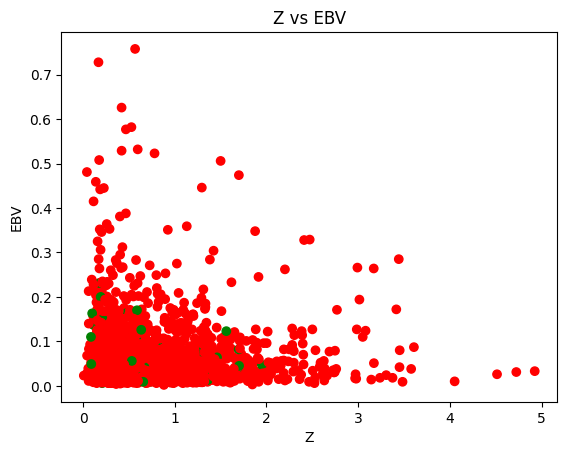

In [ ]:
import matplotlib.pyplot as plt


colors = df['target'].map({0: 'red', 1: 'green'})
plt.figure()
plt.scatter(df['Z'], df['EBV'], c=colors)
plt.xlabel('Z')
plt.ylabel('EBV')
plt.title('Z vs EBV')
plt.show()

In [ ]:
df = df[["object_id","target"] + feature_cols]

In [ ]:
empty_cols = [c for c in feature_cols if train_features[c].isna().all()]
print("Dropping empty columns:", empty_cols)

df=df.drop(columns=empty_cols)

Dropping empty columns: ['Z_err']


In [ ]:
feature_cols = [c for c in feature_cols if c not in empty_cols]
medians = df[feature_cols].median()
df[feature_cols] = df[feature_cols].fillna(medians)

#### Model

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

X = df[feature_cols]
y = df["target"]
groups = train_features["object_id"]

In [ ]:
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos = neg / pos
print("scale_pos_weight:", scale_pos)

scale_pos_weight: 19.56081081081081


In [ ]:
# !pip install catboost

In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

gkf = GroupKFold(n_splits=5)
oof_probs = np.zeros(len(y))

for fold, (tr, va) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]

    lgb = LGBMClassifier(
        n_estimators=900,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.90,
        colsample_bytree=0.85,
        reg_alpha=0.01,
        reg_lambda=1.0,
        class_weight="balanced",
        device_type='gpu',
        verbosity=-1
    )
    cat = CatBoostClassifier(
        iterations=1050,
        depth=5,
        learning_rate=0.01,
        loss_function="Logloss",
        auto_class_weights="Balanced",
        verbose=0,
        task_type="GPU"
    )
    xgb = XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        colsample_bytree=0.90,
        scale_pos_weight=scale_pos,
        tree_method="hist",
        device="gpu",
        verbosity=0
    )
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    p_lgb = lgb.predict_proba(X_va)[:,1]
    p_cat = cat.predict_proba(X_va)[:,1]
    p_xgb = xgb.predict_proba(X_va)[:,1]

    oof_probs[va] = 0.25*p_cat + 0.30*p_xgb + 0.45*p_lgb

In [ ]:
best_f1 = 0
best_t = 0

for t in np.linspace(0.05, 0.98, 40):
    preds = (oof_probs > t).astype(int)
    f1 = f1_score(y, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best F1:", best_f1)
print("Best threshold:", best_t)

Best F1: 0.36363636363636365
Best threshold: 0.16923076923076924


In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

X = df[feature_cols]
y = df["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

lgb = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.90,
    colsample_bytree=0.85,
    reg_alpha=0.01,
    reg_lambda=1.0,
    class_weight="balanced",
    device_type='gpu',
    verbosity=-1
)
cat_final = CatBoostClassifier(
    iterations=1050,
    depth=5,
    learning_rate=0.01,
    l2_leaf_reg=6,
    auto_class_weights="Balanced",
    verbose=0,
    task_type="GPU"
)
xgb_final = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    colsample_bytree=0.90,
    scale_pos_weight=scale_pos,
    tree_method="hist",
    verbosity=0,
    device="gpu"
)
lgb.fit(X_train, y_train)
cat_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device='gpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred_cat=cat_final.predict_proba(X_test)[:,1]
pred_xgb=xgb_final.predict_proba(X_test)[:,1]
pred_lgb=lgb.predict_proba(X_test)[:,1]

pred = 0.25*pred_cat + 0.30*pred_xgb + 0.45*pred_lgb
pred=(pred>0.13).astype(int)
f1_score(y_test, pred)

0.4044943820224719

## Test

In [ ]:
test_rows = []

for _, row in test_log.iterrows():
    obj = row["object_id"]
    split = row["split"]

    lc = pd.read_csv(f"{BASE_PATH}/{split}/test_full_lightcurves.csv")
    lc = lc[lc["object_id"] == obj]

    feats = build_object_features(lc, row)
    feats["object_id"] = obj

    test_rows.append(feats)

test_features = pd.DataFrame(test_rows)
print(test_features.shape)

(7135, 53)


In [ ]:
df_test = test_features
feature_cols = [c for c in df.columns if c not in ["object_id","target"]]
df_test = df_test[["object_id"] + feature_cols]
empty_cols = [c for c in feature_cols if train_features[c].isna().all()]
df_test=df_test.drop(columns=empty_cols)

In [ ]:
feature_cols = [c for c in feature_cols if c not in empty_cols]
df_test[feature_cols]  = df_test[feature_cols].fillna(medians)

In [ ]:
assert list(df[feature_cols].columns) == list(df_test[feature_cols].columns)
assert df[feature_cols].isna().sum().sum() == 0
assert df_test[feature_cols].isna().sum().sum() == 0
print("Schema locked")

Schema locked


In [ ]:
X_test = df_test[feature_cols]

pred_lgb = lgb.predict_proba(X_test)[:,1]
pred_cat = cat_final.predict_proba(X_test)[:,1]
pred_xgb = xgb_final.predict_proba(X_test)[:,1]

p_test = 0.25*pred_cat + 0.30*pred_xgb + 0.45*pred_lgb

threshold = 0.13
y_test_pred = (p_test > threshold).astype(int)

In [ ]:
submission = pd.DataFrame({
    "object_id": test_features["object_id"],
    "prediction": y_test_pred
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved")

submission.csv saved
